In [32]:
import matplotlib.pyplot as plt
import numpy as np

In [33]:
def create_Hamiltonian(num_qubits, J, J_parallel):
    return np.diag([J] * (num_qubits-1),k=1) + np.diag([J] * (num_qubits-1),k=-1) + np.diag([J_parallel] * (num_qubits - 2), k=2) + np.diag([J_parallel] * (num_qubits - 2), k=-2)

def get_eigenvalues_and_vectors(H):
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    sorted_indices = np.argsort(eigenvalues)
    return eigenvalues[sorted_indices], eigenvectors[:, sorted_indices]

def analyze_state(state, current_operators, bond_operators):
    currents = np.real([state.conj().T @ current_op @ state for current_op in current_operators])
    current_correlations = np.zeros((len(current_operators), len(current_operators)))
    for i in range(len(current_operators)):
        for j in range(len(current_operators)):
            if abs(i - j) > 1:
                current_correlations[i, j] = np.real((state.conj().T @ current_operators[i] @ current_operators[j] @ state) - currents[i]*currents[j])
    
    bond_values = np.real([state.conj().T @ bond_op @ state for bond_op in bond_operators])
    return currents, current_correlations, bond_values

0 flux eigenvalues: [-3.99521627e+00 -3.98088078e+00 -3.95704066e+00 -3.92377421e+00
 -3.88119069e+00 -3.82942986e+00 -3.76866150e+00 -3.69908478e+00
 -3.62092754e+00 -3.53444545e+00 -3.43992106e+00 -3.33766280e+00
 -3.22800385e+00 -3.11130092e+00 -2.98793298e+00 -2.85829987e+00
 -2.72282089e+00 -2.58193331e+00 -2.43609080e+00 -2.28576188e+00
 -2.13142831e+00 -1.97358345e+00 -1.81273069e+00 -1.64938190e+00
 -1.48405597e+00 -1.31727761e+00 -1.14957643e+00 -9.81486731e-01
 -8.13548642e-01 -6.46312077e-01 -4.80347977e-01 -3.16281975e-01
 -1.54930583e-01  2.01941495e-16  3.88919196e-03  1.13512301e-02
  2.66350460e-02  4.50040344e-02  7.14028625e-02  9.93033513e-02
  1.37108481e-01  1.53252833e-01  1.85130295e-01  2.21341826e-01
  2.74831879e-01  3.02565549e-01  3.41252585e-01  3.83039312e-01
  4.50383696e-01  4.61554511e-01  5.24240014e-01  5.71228057e-01
  6.25073955e-01  6.53568345e-01  7.34195121e-01  7.49345528e-01
  8.19928606e-01  8.62236380e-01  9.19060510e-01  9.57086103e-01
  1.0

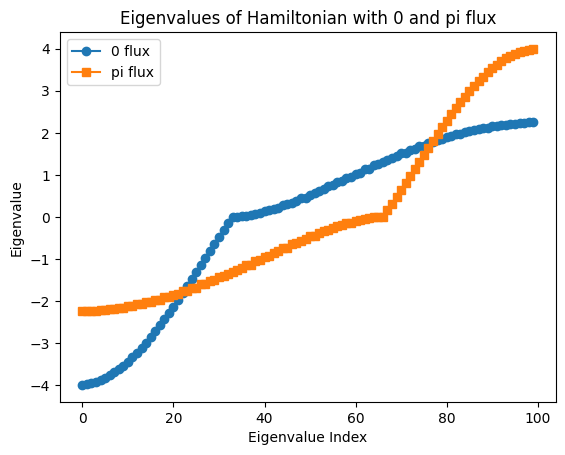

pi flux eigenvalues: [-2.24648730e+00 -2.24639981e+00 -2.23597315e+00 -2.23560715e+00
 -2.21852800e+00 -2.21764710e+00 -2.19426432e+00 -2.19256626e+00
 -2.16332837e+00 -2.16044146e+00 -2.12588721e+00 -2.12139452e+00
 -2.08210963e+00 -2.07561510e+00 -2.03214026e+00 -2.02339209e+00
 -1.97606727e+00 -1.96514824e+00 -1.91389015e+00 -1.90145992e+00
 -1.84550741e+00 -1.83302946e+00 -1.77076047e+00 -1.76058773e+00
 -1.68956654e+00 -1.68475798e+00 -1.60594553e+00 -1.60213773e+00
 -1.52424967e+00 -1.50929380e+00 -1.43927497e+00 -1.41297961e+00
 -1.34966424e+00 -1.31666704e+00 -1.25272192e+00 -1.22354549e+00
 -1.14635850e+00 -1.13373207e+00 -1.04563442e+00 -1.03255127e+00
 -9.57086103e-01 -9.19060510e-01 -8.62236380e-01 -8.19928606e-01
 -7.49345528e-01 -7.34195121e-01 -6.53568345e-01 -6.25073955e-01
 -5.71228057e-01 -5.24240014e-01 -4.61554511e-01 -4.50383696e-01
 -3.83039312e-01 -3.41252585e-01 -3.02565549e-01 -2.74831879e-01
 -2.21341826e-01 -1.85130295e-01 -1.53252833e-01 -1.37108481e-01
 -9.

In [34]:
J = -1
J_parallel = J

num_qubits = 100

H_0 = create_Hamiltonian(num_qubits, J, J_parallel)
eigenvalues_0, eigenvectors_0 = get_eigenvalues_and_vectors(H_0)
print(f'0 flux eigenvalues: {eigenvalues_0}')

H_pi = create_Hamiltonian(num_qubits, J, -J_parallel)
eigenvalues_pi, eigenvectors_pi = get_eigenvalues_and_vectors(H_pi)

plt.plot(eigenvalues_0, marker='o', label='0 flux')
plt.plot(eigenvalues_pi, marker='s', label='pi flux')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of Hamiltonian with 0 and pi flux')
plt.legend()
plt.show()

print(f'pi flux eigenvalues: {eigenvalues_pi}')


In [35]:
bond_operators = []
for i in range(num_qubits-1):
    bond_op = np.zeros((num_qubits, num_qubits))
    bond_op[i, i+1] = 1
    bond_op[i+1, i] = 1
    bond_operators.append(bond_op)

current_operators = []
for i in range(num_qubits-1):
    current_op = np.zeros((num_qubits, num_qubits), dtype=complex)
    current_op[i, i+1] = -1j
    current_op[i+1, i] = 1j
    current_operators.append(current_op)

In [36]:
ground_state_0 = eigenvectors_0[:, 0]
currents_0, current_correlations_0, bond_values_0 = analyze_state(ground_state_0, current_operators, bond_operators)

ground_state_pi = eigenvectors_pi[:, 0]
currents_pi, current_correlations_pi, bond_values_pi = analyze_state(ground_state_pi, current_operators, bond_operators)

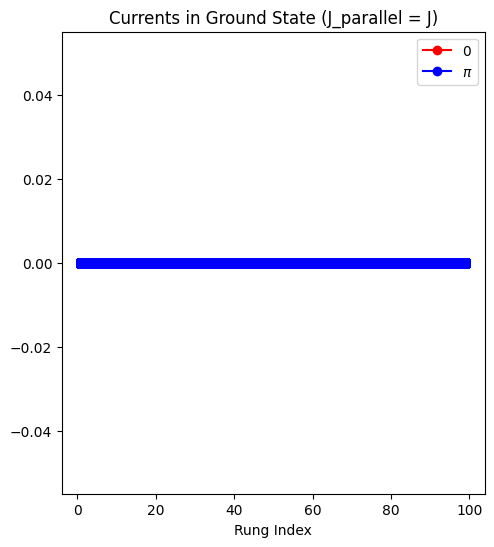

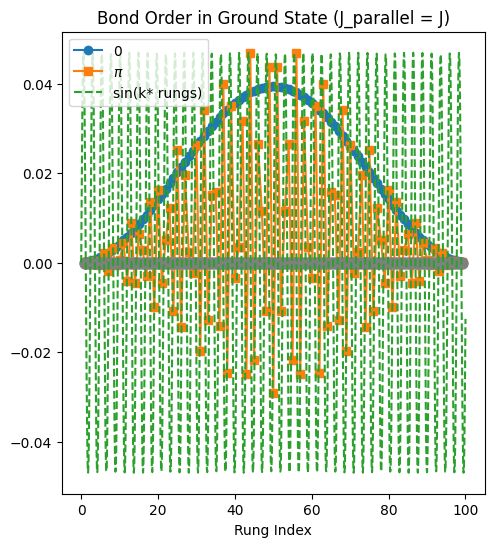

In [37]:
rungs = range(1, num_qubits)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

plt.plot(rungs, currents_0, color='red',marker='o', label='0')
plt.plot(rungs, currents_pi, color='blue', marker='o', label='$\pi$')

plt.plot(rungs, current_correlations_0, color='red',marker='s')
plt.plot(rungs, current_correlations_pi, color='blue', marker='s')

plt.title('Currents in Ground State (J_parallel = J)')
plt.xlabel('Rung Index')
plt.legend()
plt.show()



plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(rungs, bond_values_0, marker='o', label='0')
plt.plot(rungs, bond_values_pi, marker='s', label='$\pi$')

plt.plot()

plt.plot(rungs, [0]*len(rungs), color='gray', linestyle='', marker='o', ms=8)

k_star = 2 * np.arccos(1/4)
# k_star = np.pi
x_values = np.linspace(0, num_qubits, 1001)

plt.plot(x_values, np.max(bond_values_pi)*np.sin(k_star * x_values), label='sin(k* rungs)', linestyle='--')

plt.title('Bond Order in Ground State (J_parallel = J)')
plt.xlabel('Rung Index')
plt.legend()
plt.show()

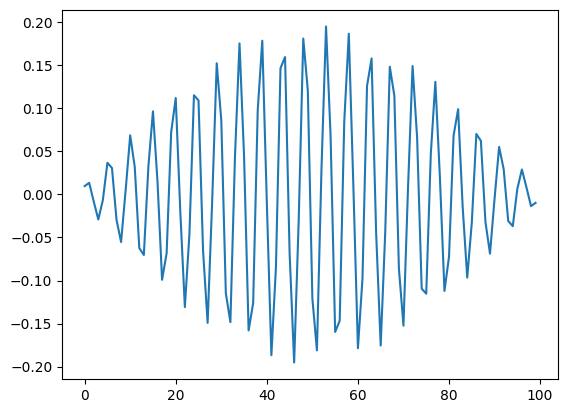

In [38]:
plt.plot(ground_state_pi.real)

In [39]:
u1 = np.array([0.176777 + 0.684653j, 1/np.sqrt(2)])
print(np.angle(u1))
print(2*np.arccos(1/4))
print(np.arccos(1/4))

[1.31811558 0.        ]
2.636232143305636
1.318116071652818


In [40]:
u1 = np.array([0.176777 + 0.684653j, 1/np.sqrt(2)])
print(np.angle(u1))
print(2*np.arccos(1/4))
print(np.arccos(1/4))

[1.31811558 0.        ]
2.636232143305636
1.318116071652818


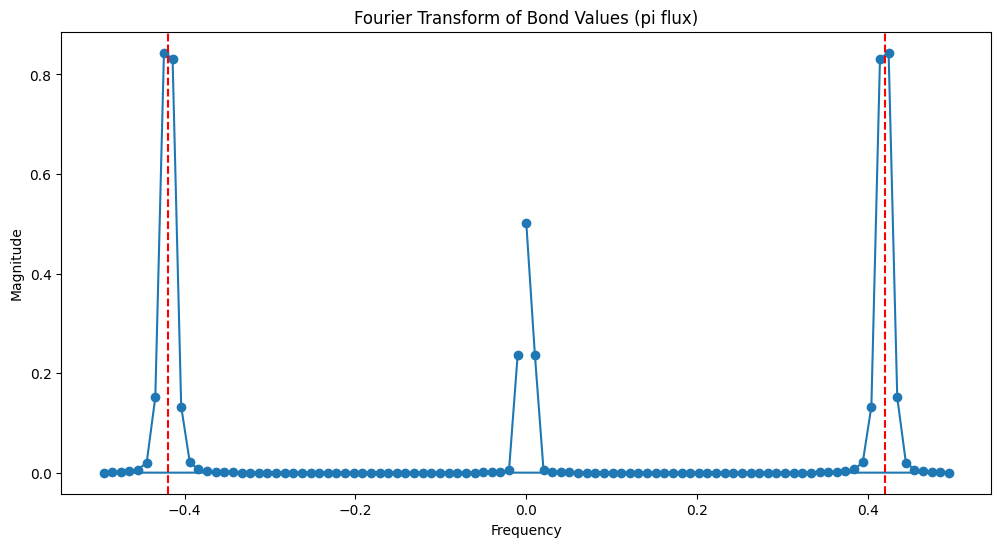

In [41]:
### fourier transform of bond values
bond_values_pi_ft = np.fft.fft(bond_values_pi)
frequencies = np.fft.fftfreq(len(bond_values_pi), d=1)
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(bond_values_pi_ft), marker='o')

plt.axvline(x=k_star/(2*np.pi), color='red', linestyle='--', label='k*')
plt.axvline(x=-k_star/(2*np.pi), color='red', linestyle='--')


plt.title('Fourier Transform of Bond Values (pi flux)')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.show()


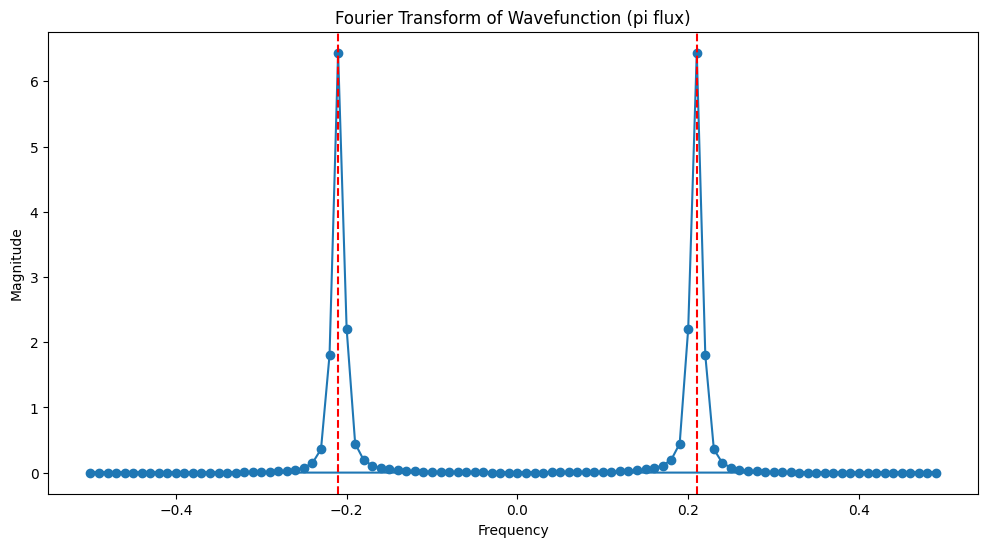

In [42]:
### fourier transform of wavefunction
wavefunction_ft = np.fft.fft(ground_state_pi)
frequencies = np.fft.fftfreq(len(ground_state_pi), d=1)
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(wavefunction_ft), marker='o')

plt.axvline(x=k_star/2/(2*np.pi), color='red', linestyle='--', label='k*')
plt.axvline(x=-k_star/2/(2*np.pi), color='red', linestyle='--')


plt.title('Fourier Transform of Wavefunction (pi flux)')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.show()


In [43]:
# calculate bond order parameter

bond_order_parameter_0 = 0
for i in range(len(bond_values_0)):
    bond_order_parameter_0 += bond_values_0[i] * (-1)**i


bond_order_parameter_pi= 0
for i in range(len(bond_values_pi)):
    bond_order_parameter_pi += bond_values_pi[i] * (-1)**i

print(f'Bond order parameter for 0 flux: {bond_order_parameter_0}')
print(f'Bond order parameter for pi flux: {bond_order_parameter_pi}')

Bond order parameter for 0 flux: 7.020645345739765e-05
Bond order parameter for pi flux: -0.0006524790221893101
